# 15-2 · Leverage (Hat Values)

El **leverage** mide qué tan inusuales son los valores de los predictores ($X$) de una observación respecto al resto del dataset.

En este notebook:
1. Entendemos la intuición detrás del leverage
2. Calculamos la hat matrix a mano y con statsmodels
3. Identificamos puntos de alto leverage
4. Visualizamos por qué importa
5. Entendemos la diferencia entre alto leverage y ser influyente

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

df = pd.read_csv("../data/housing.csv")
print(f"Filas: {len(df)}")
df.head(3)

Filas: 100


,id,square_meters,age,price,bedrooms,bathrooms,floor,distance_to_center_km,has_garage,build_quality,property_type,neighborhood
0,1,152,33,338200,4,2,1,4.3,1,10,Single Family,El Prado
1,2,142,24,266900,4,3,8,6.6,1,3,Single Family,Las Flores
2,3,64,11,170800,2,1,1,14.0,1,6,Apartment,El Mirador


In [2]:
# --- Modelo base ---
predictors = [
    "square_meters",
    "bedrooms",
    "bathrooms",
    "build_quality",
    "age",
    "distance_to_center_km",
    "has_garage",
]

X = np.asarray(df[predictors])
y = np.asarray(df["price"])
n, p = X.shape

X_const = sm.add_constant(X)
ols = sm.OLS(y, X_const).fit()
influence = ols.get_influence()

y_pred = ols.fittedvalues
e = ols.resid
std_resid = influence.resid_studentized_internal
leverage = influence.hat_matrix_diag

print(f"R² = {ols.rsquared:.4f}")
print(f"n = {n}, p = {p}")

R² = 0.8713
n = 100, p = 7


## 1 · Intuición: ¿qué es el leverage?

Imagina que tiras una recta de regresión. Los puntos **cercanos al centro** de los datos tienen poco poder para mover la recta. Pero un punto **alejado del centro** en el espacio de $X$ puede "tirar" la recta hacia sí mismo.

El leverage $h_{ii}$ cuantifica ese poder:

- $h_{ii}$ está entre $1/n$ y $1$
- Es alto cuando los **predictores** de la observación $i$ son inusuales
- **No depende de $y$** — solo de la posición en el espacio de $X$

## 2 · La Hat Matrix

El leverage proviene de la **hat matrix** ("matriz sombrero"), llamada así porque transforma $y$ en $\hat{y}$:

$$\hat{y} = Hy \quad \text{donde} \quad H = X(X^TX)^{-1}X^T$$

El leverage de la observación $i$ es el elemento diagonal $h_{ii}$ de $H$.

Cada $h_{ii}$ indica cuánto peso tiene la observación $i$ sobre su propia predicción.

In [3]:
# --- Cálculo manual ---
XtX_inv = np.linalg.inv(X_const.T @ X_const)
H = X_const @ XtX_inv @ X_const.T
lev_manual = np.diag(H)

# Verificar contra statsmodels
print(f"¿Coincide con statsmodels? {np.allclose(lev_manual, leverage)} ✅")
print(f"\nPropiedades de la hat matrix:")
print(
    f"  Suma de leverage (traza de H): {leverage.sum():.1f}  (debe ser p+1 = {p + 1})"
)
print(f"  Min leverage: {leverage.min():.4f}  (mínimo teórico: 1/n = {1 / n:.4f})")
print(f"  Max leverage: {leverage.max():.4f}")
print(
    f"  Media leverage: {leverage.mean():.4f}  (debe ser (p+1)/n = {(p + 1) / n:.4f})"
)

¿Coincide con statsmodels? True ✅

Propiedades de la hat matrix:
  Suma de leverage (traza de H): 8.0  (debe ser p+1 = 8)
  Min leverage: 0.0278  (mínimo teórico: 1/n = 0.0100)
  Max leverage: 0.1932
  Media leverage: 0.0800  (debe ser (p+1)/n = 0.0800)


## 3 · Umbral de Alto Leverage

Regla de dedo: una observación tiene **alto leverage** si:

$$h_{ii} > \frac{2(p+1)}{n}$$

Esto es el doble del leverage promedio. No es un test formal, sino una guía para identificar puntos que merecen atención.

In [4]:
lev_threshold = 2 * (p + 1) / n
high_lev_mask = leverage > lev_threshold
n_high = np.sum(high_lev_mask)

print(f"Umbral: 2(p+1)/n = 2·{p + 1}/{n} = {lev_threshold:.4f}")
print(f"Puntos con alto leverage: {n_high} de {n} ({100 * n_high / n:.0f}%)\n")

# Mostrar los puntos de alto leverage
high_lev_df = pd.DataFrame(
    {
        "leverage": leverage[high_lev_mask].round(4),
        "std_resid": std_resid[high_lev_mask].round(2),
        "outlier?": [
            "🚨 Sí" if abs(r) > 2 else "✅ No" for r in std_resid[high_lev_mask]
        ],
    },
    index=np.where(high_lev_mask)[0],
)
high_lev_df.index.name = "obs"
high_lev_df.sort_values("leverage", ascending=False)

Umbral: 2(p+1)/n = 2·8/100 = 0.1600
Puntos con alto leverage: 2 de 100 (2%)



,leverage,std_resid,outlier?
obs,,,
81,0.1932,-1.08,✅ No
44,0.1625,1.36,✅ No


## 4 · ¿Por qué tienen alto leverage?

Veamos qué tiene de especial cada punto de alto leverage comparando sus predictores con el promedio del dataset:

In [5]:
# Comparar predictores de high-leverage vs promedio
means = X.mean(axis=0)
stds = X.std(axis=0)

high_lev_indices = np.where(high_lev_mask)[0]

print(f"{'Predictor':>25s} {'Media':>10s} {'Std':>8s}", end="")
for idx in high_lev_indices[:5]:  # Mostrar hasta 5
    print(f" {'Obs ' + str(idx):>10s}", end="")
print()
print("-" * (45 + 11 * min(len(high_lev_indices), 5)))

for j, name in enumerate(predictors):
    print(f"{name:>25s} {means[j]:>10.1f} {stds[j]:>8.1f}", end="")
    for idx in high_lev_indices[:5]:
        val = X[idx, j]
        z_score = (val - means[j]) / stds[j]
        marker = " 🔴" if abs(z_score) > 2 else ""
        print(f" {val:>8.1f}{marker}", end="")
    print()

print("\n🔴 = más de 2 desviaciones estándar del promedio")

                Predictor      Media      Std     Obs 44     Obs 81
-------------------------------------------------------------------
            square_meters      120.4     42.5    179.0    185.0
                 bedrooms        3.4      1.2      5.0      5.0
                bathrooms        2.0      0.8      2.0      2.0
            build_quality        5.7      2.4      3.0      2.0
                      age       28.3     13.5      8.0      3.0
    distance_to_center_km       12.6      7.2     11.7     19.0
               has_garage        0.7      0.5      1.0      1.0

🔴 = más de 2 desviaciones estándar del promedio


## 5 · Visualización

/var/folders/t9/t_rpjxld77qckx9g0kl5kwn00000gn/T/ipykernel_92965/2290441463.py:67: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/angelozdev/me/practical-statistics-for-data-analysis/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


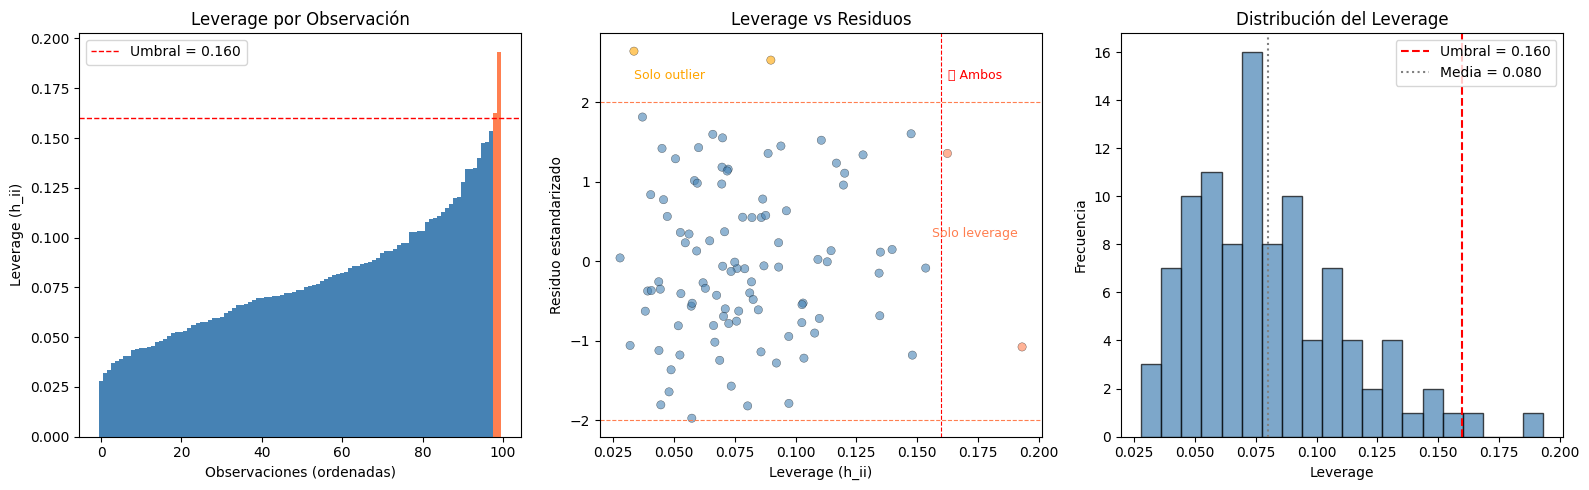

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- 1. Leverage por observación ---
ax = axes[0]
order = np.argsort(leverage)
colors = ["coral" if leverage[i] > lev_threshold else "steelblue" for i in order]
ax.bar(range(n), leverage[order], color=colors, edgecolor="none", width=1.0)
ax.axhline(
    y=lev_threshold,
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"Umbral = {lev_threshold:.3f}",
)
ax.set_xlabel("Observaciones (ordenadas)")
ax.set_ylabel("Leverage (h_ii)")
ax.set_title("Leverage por Observación")
ax.legend()

# --- 2. Leverage vs Residuos ---
ax = axes[1]
colors2 = [
    "coral"
    if leverage[i] > lev_threshold
    else ("orange" if abs(std_resid[i]) > 2 else "steelblue")
    for i in range(n)
]
ax.scatter(leverage, std_resid, c=colors2, alpha=0.6, edgecolors="k", linewidth=0.3)
ax.axhline(y=2, color="coral", linestyle="--", linewidth=0.8)
ax.axhline(y=-2, color="coral", linestyle="--", linewidth=0.8)
ax.axvline(x=lev_threshold, color="red", linestyle="--", linewidth=0.8)

# Anotar cuadrantes
ax.text(
    lev_threshold * 0.3, 2.3, "Solo outlier", fontsize=9, color="orange", ha="center"
)
ax.text(
    leverage.max() * 0.9, 0.3, "Solo leverage", fontsize=9, color="coral", ha="center"
)
ax.text(leverage.max() * 0.9, 2.3, "🚨 Ambos", fontsize=9, color="red", ha="center")
ax.set_xlabel("Leverage (h_ii)")
ax.set_ylabel("Residuo estandarizado")
ax.set_title("Leverage vs Residuos")

# --- 3. Histograma de leverage ---
ax = axes[2]
ax.hist(leverage, bins=20, color="steelblue", edgecolor="black", alpha=0.7)
ax.axvline(
    x=lev_threshold,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Umbral = {lev_threshold:.3f}",
)
ax.axvline(
    x=(p + 1) / n,
    color="gray",
    linestyle=":",
    linewidth=1.5,
    label=f"Media = {(p + 1) / n:.3f}",
)
ax.set_xlabel("Leverage")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución del Leverage")
ax.legend()

plt.tight_layout()
plt.show()

## 6 · Alto Leverage ≠ Influyente

Un punto con alto leverage **no es necesariamente un problema**:

| Leverage | Residuo | ¿Problema? |
|----------|---------|------------|
| Alto | Bajo | ✅ No — el punto sigue la tendencia, solo está lejos en X |
| Bajo | Alto | ⚠️ Outlier pero sin poder de distorsión |
| **Alto** | **Alto** | 🚨 **Sí** — tiene poder Y está lejos de la tendencia |

> 👈 Para saber si un punto de alto leverage **realmente distorsiona** el modelo, necesitamos la **distancia de Cook** (ver notebook 15-3).

In [7]:
# Demostración: efecto de un punto de alto leverage
worst_lev = np.argmax(leverage)
print(f"Punto con mayor leverage: observación {worst_lev}")
print(f"  Leverage: {leverage[worst_lev]:.4f} (umbral: {lev_threshold:.4f})")
print(f"  Residuo estandarizado: {std_resid[worst_lev]:.2f}")
print(f"  ¿Es también outlier? {'🚨 Sí' if abs(std_resid[worst_lev]) > 2 else '✅ No'}")

# Reajustar sin ese punto
mask = np.ones(n, dtype=bool)
mask[worst_lev] = False
ols_no_lev = sm.OLS(y[mask], X_const[mask]).fit()

print(f"\nR² con punto:   {ols.rsquared:.4f}")
print(f"R² sin punto:   {ols_no_lev.rsquared:.4f}")
print(f"Cambio en R²:   {ols_no_lev.rsquared - ols.rsquared:+.4f}")

# Coeficientes que más cambian
diffs = np.abs((ols_no_lev.params[1:] - ols.params[1:]) / ols.params[1:]) * 100
top_change = np.argsort(diffs)[-3:][::-1]
print(f"\nCoeficientes que más cambian:")
for j in top_change:
    print(
        f"  {predictors[j]:>25s}: {ols.params[j + 1]:>10,.1f} → {ols_no_lev.params[j + 1]:>10,.1f} ({diffs[j]:+.1f}%)"
    )

Punto con mayor leverage: observación 81
  Leverage: 0.1932 (umbral: 0.1600)
  Residuo estandarizado: -1.08
  ¿Es también outlier? ✅ No

R² con punto:   0.8713
R² sin punto:   0.8729
Cambio en R²:   +0.0016

Coeficientes que más cambian:
                  bathrooms:    8,200.6 →    6,022.5 (+26.6%)
                   bedrooms:   -4,494.6 →   -3,826.4 (+14.9%)
                        age:     -577.9 →     -622.7 (+7.7%)


## 7 · Resumen

| Concepto | Detalle |
|----------|--------|
| **Leverage** ($h_{ii}$) | Mide qué tan inusuales son los predictores de la observación |
| **Hat matrix** | $H = X(X^TX)^{-1}X^T$, leverage = diagonal |
| **Umbral** | $h_{ii} > 2(p+1)/n$ |
| **Propiedad clave** | Solo depende de $X$, no de $Y$ |
| **No es suficiente** | Alto leverage + bajo residuo = sin problema. Necesitas Cook's D para confirmar influencia. |
| **statsmodels** | `influence.hat_matrix_diag` |